# Atividade 06

Alunos:
* Raphael Friederich (rfrf@cesar.school)
* Maria Eduarda Alves (meas@cesar.school)

In [ ]:
# Importando as bibliotecas necessárias
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

In [ ]:
# # Transformação: converte para tensor e normaliza (média e desvio de MNIST)
# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.1307,), (0.3081,))
# ])

# # Dataset de treino e teste
# train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# # Subset com os primeiros 1000 para treino e 500 para validação
# train_subset = Subset(train_dataset, range(1000))
# val_subset   = Subset(test_dataset, range(500))

# # DataLoaders
# train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
# val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False)

In [ ]:
# Transformação padrão para Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# Dataset Fashion-MNIST
full_train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
full_val_dataset   = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Subsets reduzidos
train_subset = Subset(full_train_dataset, range(200))
val_subset   = Subset(full_val_dataset, range(200))

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.02MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 61.6MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.11MB/s]


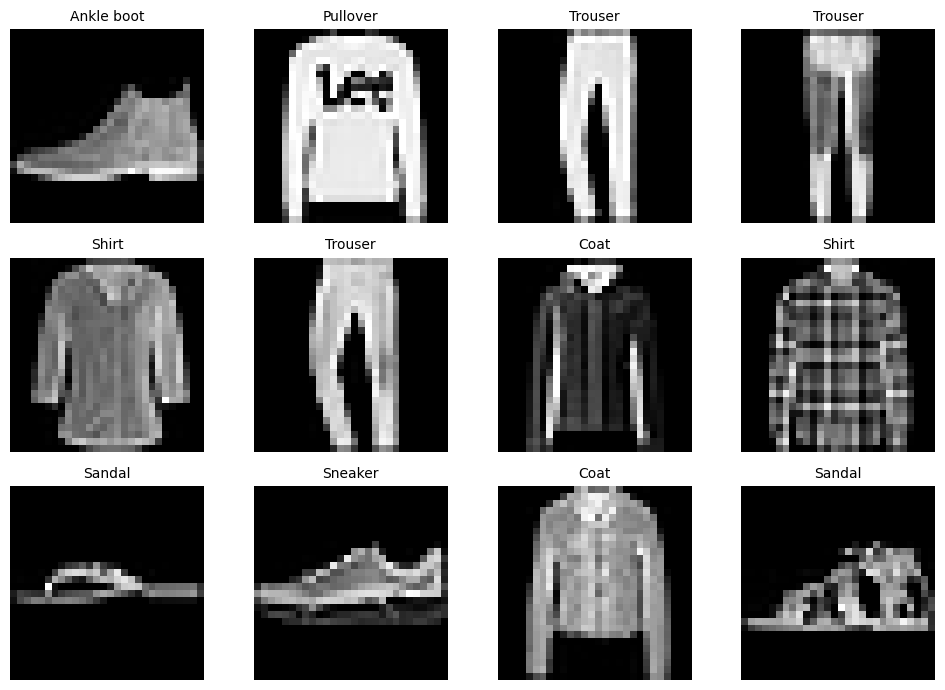

In [ ]:
# Classe names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Mostrar 12 imagens
fig, axes = plt.subplots(3, 4, figsize=(10, 7))
for i, ax in enumerate(axes.flatten()):
    img, label = val_subset[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(class_names[label], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def train_model(model, trainloader, valloader, criterion, optimizer, num_epochs=5):
    history = {
        'train_losses': [],
        'val_losses': [],
        'train_accuracies': [],
        'val_accuracies': []
    }

    for epoch in range(num_epochs):
        # Treinamento
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for i, data in tqdm(enumerate(trainloader, 0), total=len(trainloader)):
            inputs, labels = data

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc = 100 * correct / total
        history['train_losses'].append(train_loss)
        history['train_accuracies'].append(train_acc)
        print(f'Epoch {epoch+1}, Train Loss: {train_loss:.3f}, Train Accuracy: {train_acc:.2f}%')

        # Validação
        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data in valloader:
                inputs, labels = data
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(valloader)
        val_acc = 100 * correct / total
        history['val_losses'].append(val_loss)
        history['val_accuracies'].append(val_acc)
        print(f'Epoch {epoch+1}, Val Loss: {val_loss:.3f}, Val Accuracy: {val_acc:.2f}%')

    print('Treinamento concluído')
    return history


def test_model(model, testloader):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Acurácia da rede na base de teste: {100 * correct / total:.2f}%')


def plot_training_history(history):
    epochs = range(1, len(history['train_losses']) + 1)

    plt.figure(figsize=(12, 5))

    # Losses
    plt.subplot(1, 2, 1)
    plt.grid()
    plt.plot(epochs, history['train_losses'], label='Train Loss')
    plt.plot(epochs, history['val_losses'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Accuracies
    plt.subplot(1, 2, 2)
    plt.grid()
    plt.plot(epochs, history['train_accuracies'], label='Train Accuracy')
    plt.plot(epochs, history['val_accuracies'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
class CNN(nn.Module):
    def __init__(self, initialize_weights=True, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 12, 5)
        self.fc1 = nn.Linear(12 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(dropout)

        if initialize_weights:
            self._initialize_weights()

    def forward(self, x):
        # CNN
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)

        # Flatten
        x = x.view(-1, 12 * 4 * 4)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

100%|██████████| 4/4 [00:00<00:00, 13.51it/s]


Epoch 1, Train Loss: 2.290, Train Accuracy: 10.50%
Epoch 1, Val Loss: 2.284, Val Accuracy: 16.00%


100%|██████████| 4/4 [00:00<00:00, 43.77it/s]


Epoch 2, Train Loss: 2.278, Train Accuracy: 18.50%
Epoch 2, Val Loss: 2.266, Val Accuracy: 21.00%


100%|██████████| 4/4 [00:00<00:00, 33.33it/s]

...

Epoch 18, Train Loss: 0.666, Train Accuracy: 74.50%
Epoch 18, Val Loss: 0.863, Val Accuracy: 70.00%


100%|██████████| 4/4 [00:00<00:00, 46.18it/s]


Epoch 19, Train Loss: 0.586, Train Accuracy: 77.00%
Epoch 19, Val Loss: 0.807, Val Accuracy: 65.00%


100%|██████████| 4/4 [00:00<00:00, 43.67it/s]


Epoch 20, Train Loss: 0.702, Train Accuracy: 78.50%
Epoch 20, Val Loss: 0.838, Val Accuracy: 69.50%
Treinamento concluído


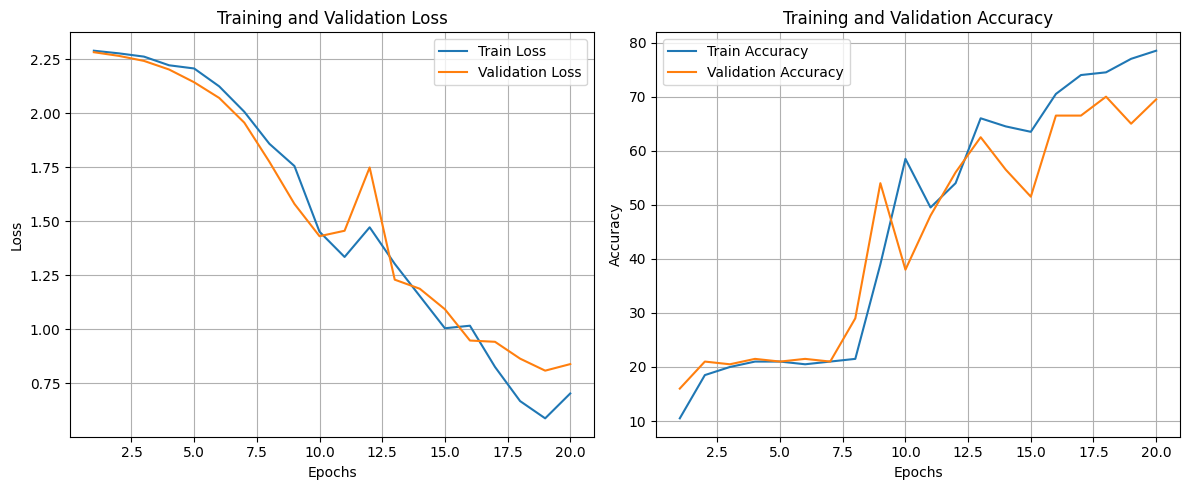

Acurácia da rede na base de teste: 69.50%


In [ ]:
model_1 = CNN(
    initialize_weights=False,
    dropout=0.0
)

criterion_1 = nn.CrossEntropyLoss()
optimizer_1 = optim.SGD(model_1.parameters(), lr=0.01, momentum=0.9)

# Treinando a CNN
history_1 = train_model(
    model=model_1,
    trainloader=train_loader,
    valloader=val_loader,
    criterion=criterion_1,
    optimizer=optimizer_1,
    num_epochs=20
)

plot_training_history(history_1)

test_model(model_1, val_loader)

100%|██████████| 4/4 [00:00<00:00, 37.61it/s]


Epoch 1, Train Loss: 2.563, Train Accuracy: 12.50%
Epoch 1, Val Loss: 2.320, Val Accuracy: 11.00%


100%|██████████| 4/4 [00:00<00:00, 44.56it/s]


Epoch 2, Train Loss: 2.280, Train Accuracy: 15.50%
Epoch 2, Val Loss: 2.275, Val Accuracy: 19.00%


100%|██████████| 4/4 [00:00<00:00, 45.10it/s]


...

Epoch 18, Train Loss: 1.059, Train Accuracy: 59.00%
Epoch 18, Val Loss: 1.010, Val Accuracy: 66.50%


100%|██████████| 4/4 [00:00<00:00, 42.46it/s]


Epoch 19, Train Loss: 0.889, Train Accuracy: 65.50%
Epoch 19, Val Loss: 1.004, Val Accuracy: 66.00%


100%|██████████| 4/4 [00:00<00:00, 43.83it/s]


Epoch 20, Train Loss: 0.801, Train Accuracy: 67.00%
Epoch 20, Val Loss: 0.999, Val Accuracy: 64.50%
Treinamento concluído


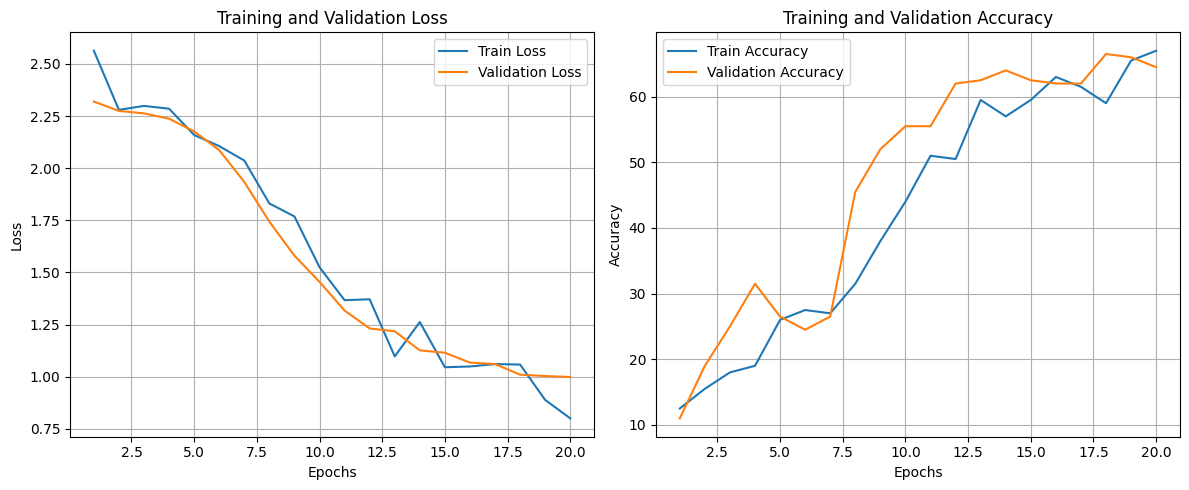

Acurácia da rede na base de teste: 64.50%


In [ ]:
model_2 = CNN(
    initialize_weights=True,
    dropout=0.5
)

criterion_2 = nn.CrossEntropyLoss()
optimizer_2 = optim.SGD(model_2.parameters(), lr=0.01, momentum=0.9)

# Treinando a CNN
history_2 = train_model(
    model=model_2,
    trainloader=train_loader,
    valloader=val_loader,
    criterion=criterion_2,
    optimizer=optimizer_2,
    num_epochs=20
)

plot_training_history(history_2)

test_model(model_2, val_loader)

## Exercícios

### Exercício 1
Na CNN implementada, execute experimentos variando:
- O número de filtros convolucionais em `self.conv1` (6 e 8)
- O número de filtros convolucionais em `self.conv2` (12 e 16)

Ao final, observe qual combinação desempenha melhor no conjunto de testes.

Dica: Adicionar argumentos no construtor da classe para determinar o número de filtros em cada camada pode ser útil para inicializar diversos modelos.

In [ ]:
class CNN_Alt(nn.Module):
    def __init__(self, initialize_weights=True, dropout=0.2,out_c1 = 6, out_c2 = 12):
        super().__init__()
        self.conv1 = nn.Conv2d(1,out_c1,5)
        self.conv2 = nn.Conv2d(out_c1, out_c2, 5)
        self.fc1 = nn.Linear(out_c2 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(dropout)
        self.out_c2 = out_c2

        if initialize_weights:
            self._initialize_weights()

    def forward(self, x):
        # CNN
        x = F.relu(self.conv1(x))
        #print(x.shape)
        x = F.max_pool2d(x, 2, 2)
        #print(x.shape)
        x = F.relu(self.conv2(x))
        #print(x.shape)
        x = F.max_pool2d(x, 2, 2)
        #print(x.shape)

        # Flatten
        x = x.view(-1, self.out_c2 * 4 * 4)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

# x = torch.randn(1, 1, 28, 28)
# cnn_model = CNN_Alt(out_c1=8,out_c2=16)
# cnn_model(x)

Iniciando o treinamento para a combinação (6, 8)


100%|██████████| 4/4 [00:00<00:00, 44.78it/s]


Epoch 1, Train Loss: 2.335, Train Accuracy: 10.00%
Epoch 1, Val Loss: 2.291, Val Accuracy: 12.00%


100%|██████████| 4/4 [00:00<00:00, 42.43it/s]


Epoch 2, Train Loss: 2.334, Train Accuracy: 17.00%
Epoch 2, Val Loss: 2.257, Val Accuracy: 21.50%


...

Epoch 18, Train Loss: 1.134, Train Accuracy: 66.00%
Epoch 18, Val Loss: 1.039, Val Accuracy: 64.50%


100%|██████████| 4/4 [00:00<00:00, 44.00it/s]


Epoch 19, Train Loss: 1.002, Train Accuracy: 62.00%
Epoch 19, Val Loss: 1.011, Val Accuracy: 66.00%


100%|██████████| 4/4 [00:00<00:00, 45.46it/s]


Epoch 20, Train Loss: 0.852, Train Accuracy: 68.00%
Epoch 20, Val Loss: 1.132, Val Accuracy: 66.00%
Treinamento concluído


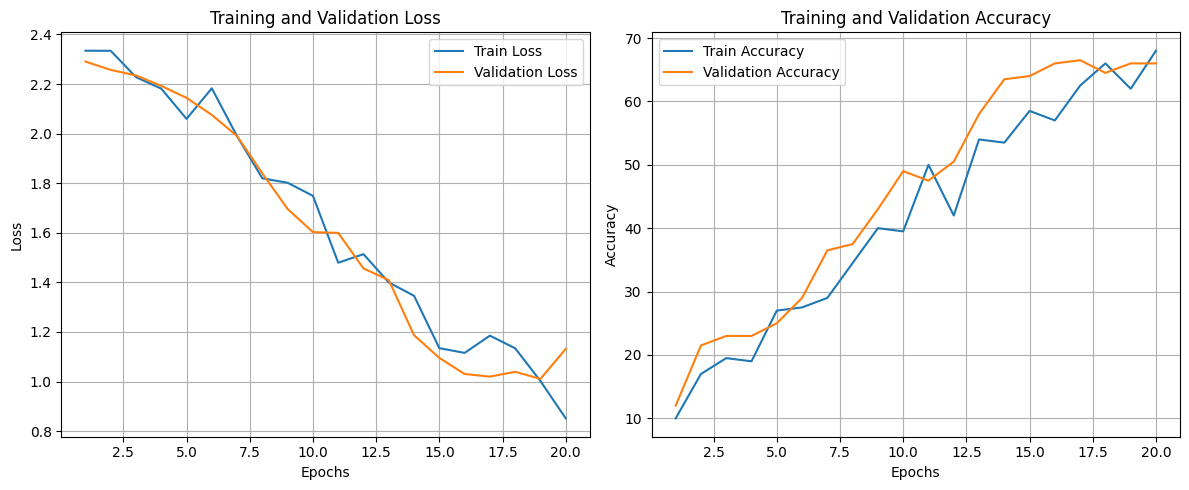

Acurácia da rede na base de teste: 66.00%
----------------------------------------------------------------------------------------------------
Iniciando o treinamento para a combinação (6, 16)


100%|██████████| 4/4 [00:00<00:00, 40.90it/s]


Epoch 1, Train Loss: 2.371, Train Accuracy: 11.00%
Epoch 1, Val Loss: 2.291, Val Accuracy: 11.50%


100%|██████████| 4/4 [00:00<00:00, 44.34it/s]


Epoch 2, Train Loss: 2.260, Train Accuracy: 16.00%
Epoch 2, Val Loss: 2.239, Val Accuracy: 15.50%


...

Epoch 18, Train Loss: 0.874, Train Accuracy: 70.50%
Epoch 18, Val Loss: 0.938, Val Accuracy: 69.00%


100%|██████████| 4/4 [00:00<00:00, 41.36it/s]


Epoch 19, Train Loss: 0.710, Train Accuracy: 67.00%
Epoch 19, Val Loss: 0.911, Val Accuracy: 69.50%


100%|██████████| 4/4 [00:00<00:00, 44.04it/s]


Epoch 20, Train Loss: 1.028, Train Accuracy: 67.50%
Epoch 20, Val Loss: 0.849, Val Accuracy: 71.00%
Treinamento concluído


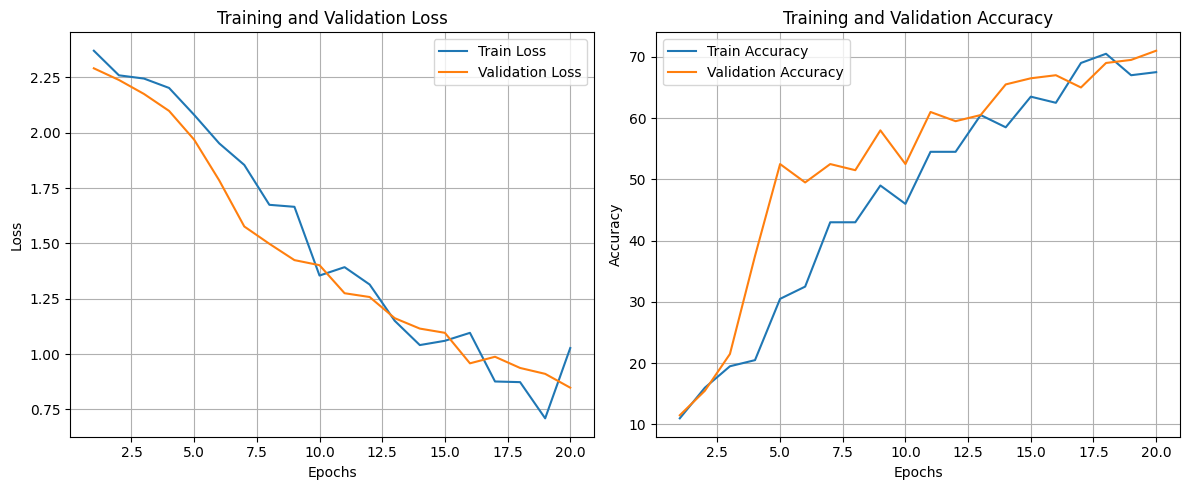

Acurácia da rede na base de teste: 71.00%
----------------------------------------------------------------------------------------------------
Iniciando o treinamento para a combinação (12, 8)


100%|██████████| 4/4 [00:00<00:00, 27.51it/s]

Epoch 1, Train Loss: 2.440, Train Accuracy: 10.50%


Epoch 1, Val Loss: 2.278, Val Accuracy: 9.50%


100%|██████████| 4/4 [00:00<00:00, 34.15it/s]


...

Epoch 18, Train Loss: 0.845, Train Accuracy: 66.50%
Epoch 18, Val Loss: 0.997, Val Accuracy: 61.00%


100%|██████████| 4/4 [00:00<00:00, 35.72it/s]


Epoch 19, Train Loss: 1.009, Train Accuracy: 68.50%
Epoch 19, Val Loss: 0.961, Val Accuracy: 66.00%


100%|██████████| 4/4 [00:00<00:00, 35.03it/s]


Epoch 20, Train Loss: 1.084, Train Accuracy: 65.50%
Epoch 20, Val Loss: 0.930, Val Accuracy: 70.50%
Treinamento concluído


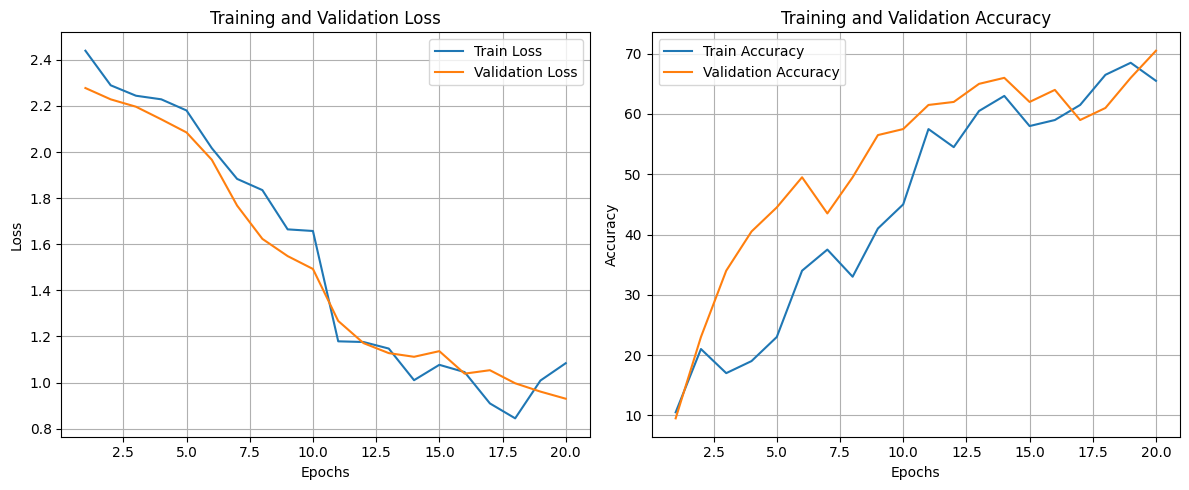

Acurácia da rede na base de teste: 70.50%
----------------------------------------------------------------------------------------------------
Iniciando o treinamento para a combinação (12, 16)


100%|██████████| 4/4 [00:00<00:00, 32.39it/s]

Epoch 1, Train Loss: 2.469, Train Accuracy: 6.50%


Epoch 1, Val Loss: 2.258, Val Accuracy: 14.00%


100%|██████████| 4/4 [00:00<00:00, 32.45it/s]

...

Epoch 18, Train Loss: 0.721, Train Accuracy: 68.50%
Epoch 18, Val Loss: 0.910, Val Accuracy: 68.00%


100%|██████████| 4/4 [00:00<00:00, 22.24it/s]


Epoch 19, Train Loss: 0.805, Train Accuracy: 69.00%
Epoch 19, Val Loss: 0.902, Val Accuracy: 65.50%


100%|██████████| 4/4 [00:00<00:00, 22.75it/s]


Epoch 20, Train Loss: 0.782, Train Accuracy: 69.50%
Epoch 20, Val Loss: 0.863, Val Accuracy: 66.00%
Treinamento concluído


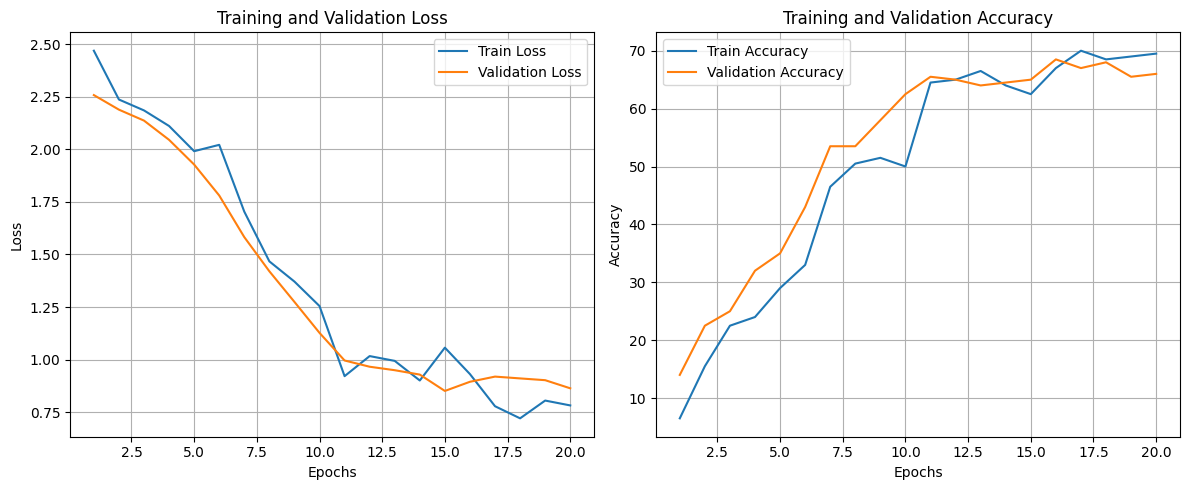

Acurácia da rede na base de teste: 66.00%
----------------------------------------------------------------------------------------------------


In [ ]:
filtro_1 = [6,12]
filtro_2 = [8,16]

for num_1 in filtro_1:
  for num_2 in filtro_2:
    print(f"Iniciando o treinamento para a combinação {num_1,num_2}")
    model_ = CNN_Alt(
      initialize_weights=True,
      dropout=0.5,
      out_c1=num_1,
      out_c2=num_2
  )

    criterion_1 = nn.CrossEntropyLoss()
    optimizer_1 = optim.SGD(model_.parameters(), lr=0.01, momentum=0.9)

    # Treinando a CNN
    history_1 = train_model(
        model=model_,
        trainloader=train_loader,
        valloader=val_loader,
        criterion=criterion_1,
        optimizer=optimizer_1,
        num_epochs=20
    )

    plot_training_history(history_1)

    test_model(model_, val_loader)
    print('-'*100)

Observações:
* combinação 6 e 8 : 66%
* combinação 6 e 16: 71%
* combinação 12 e 8: 70,50%
* combinação 12 e 16: 66%

### Exercício 2

Na CNN implementada, execute 5 treinamentos variando aleatoriamente o número de neurônios de saída em `self.fc1` (o valor atual é 64 e também deve ser alterado na entrada da próxima camada).

Como você determinaria qual foi o melhor valor?

In [ ]:
class CNN_Alt(nn.Module):
    def __init__(self, initialize_weights=True, dropout=0.2,out_c1 = 6, out_c2 = 12,out_fc1=64):
        super().__init__()
        self.conv1 = nn.Conv2d(1,out_c1,5)
        self.conv2 = nn.Conv2d(out_c1, out_c2, 5)
        self.fc1 = nn.Linear(out_c2 * 4 * 4, out_fc1)
        self.fc2 = nn.Linear(out_fc1, 10)
        self.dropout = nn.Dropout(dropout)
        self.out_c2 = out_c2

        if initialize_weights:
            self._initialize_weights()

    def forward(self, x):
        # CNN
        x = F.relu(self.conv1(x))
        #print(x.shape)
        x = F.max_pool2d(x, 2, 2)
        #print(x.shape)
        x = F.relu(self.conv2(x))
        #print(x.shape)
        x = F.max_pool2d(x, 2, 2)
        #print(x.shape)

        # Flatten
        x = x.view(-1, self.out_c2 * 4 * 4)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

Iniciando o treinamento para a combinação (6, 8)


100%|██████████| 4/4 [00:00<00:00, 42.67it/s]


Epoch 1, Train Loss: 2.343, Train Accuracy: 14.00%
Epoch 1, Val Loss: 2.278, Val Accuracy: 22.00%


100%|██████████| 4/4 [00:00<00:00, 45.16it/s]


Epoch 2, Train Loss: 2.302, Train Accuracy: 12.50%
Epoch 2, Val Loss: 2.243, Val Accuracy: 24.50%


...

Epoch 18, Train Loss: 1.073, Train Accuracy: 65.00%
Epoch 18, Val Loss: 0.862, Val Accuracy: 69.00%


100%|██████████| 4/4 [00:00<00:00, 45.86it/s]


Epoch 19, Train Loss: 0.707, Train Accuracy: 67.50%
Epoch 19, Val Loss: 0.834, Val Accuracy: 66.50%


100%|██████████| 4/4 [00:00<00:00, 47.32it/s]


Epoch 20, Train Loss: 1.009, Train Accuracy: 71.50%
Epoch 20, Val Loss: 0.810, Val Accuracy: 67.50%
Treinamento concluído
Número de neurônios na camada fully connected: 75


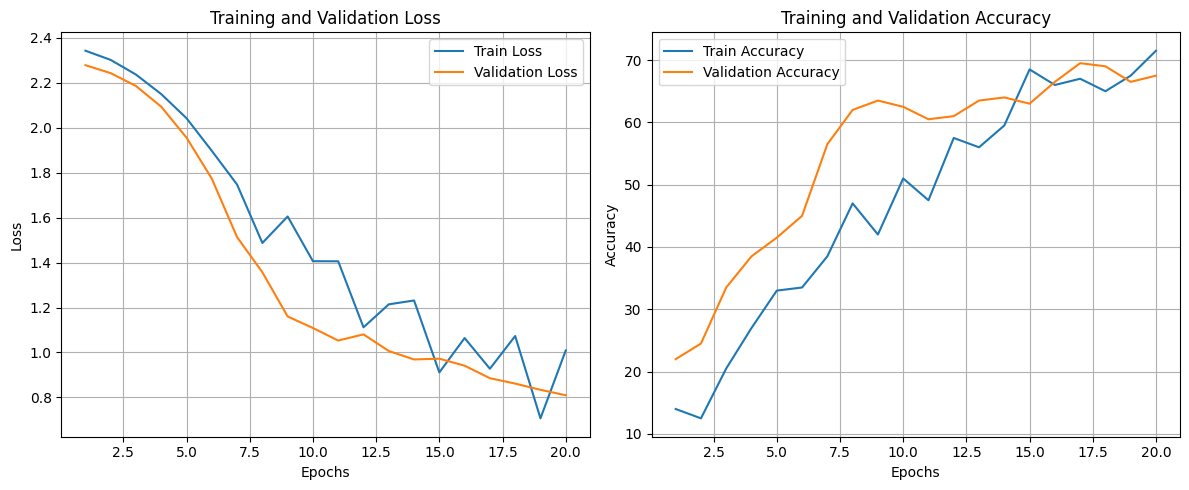

Acurácia da rede na base de teste: 67.50%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 44.07it/s]


Epoch 1, Train Loss: 2.390, Train Accuracy: 11.00%
Epoch 1, Val Loss: 2.293, Val Accuracy: 9.00%


100%|██████████| 4/4 [00:00<00:00, 44.29it/s]


Epoch 2, Train Loss: 2.301, Train Accuracy: 11.50%
Epoch 2, Val Loss: 2.286, Val Accuracy: 15.50%


...

Epoch 18, Train Loss: 1.059, Train Accuracy: 62.50%
Epoch 18, Val Loss: 1.073, Val Accuracy: 61.50%


100%|██████████| 4/4 [00:00<00:00, 37.67it/s]


Epoch 19, Train Loss: 0.958, Train Accuracy: 62.50%
Epoch 19, Val Loss: 1.072, Val Accuracy: 64.50%


100%|██████████| 4/4 [00:00<00:00, 44.16it/s]


Epoch 20, Train Loss: 0.810, Train Accuracy: 64.50%
Epoch 20, Val Loss: 1.042, Val Accuracy: 63.50%
Treinamento concluído
Número de neurônios na camada fully connected: 77


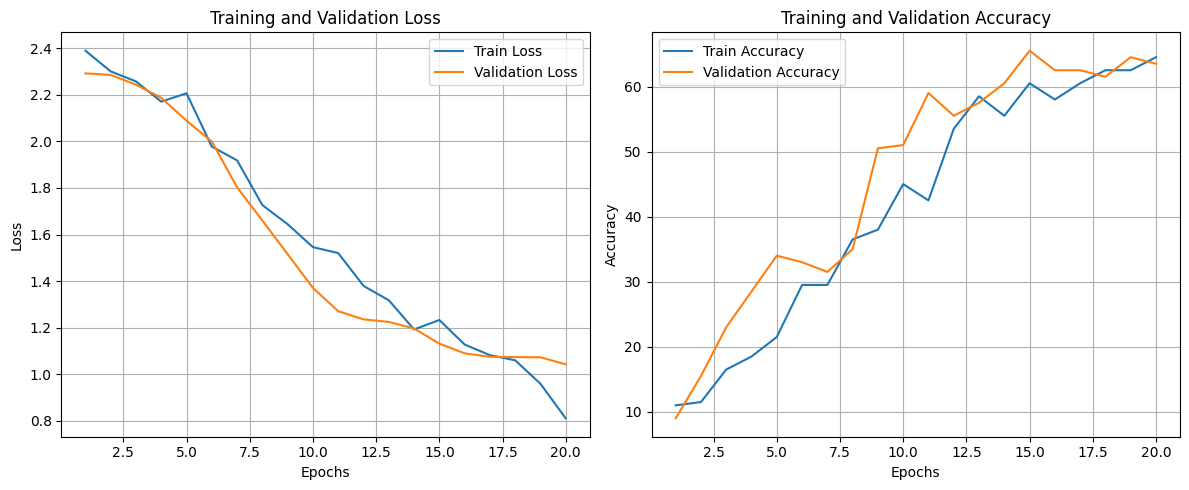

Acurácia da rede na base de teste: 63.50%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 45.23it/s]


Epoch 1, Train Loss: 2.665, Train Accuracy: 7.00%
Epoch 1, Val Loss: 2.274, Val Accuracy: 11.50%


100%|██████████| 4/4 [00:00<00:00, 43.04it/s]


Epoch 2, Train Loss: 2.282, Train Accuracy: 16.00%
Epoch 2, Val Loss: 2.246, Val Accuracy: 25.50%


...

Epoch 18, Val Loss: 1.067, Val Accuracy: 61.50%


100%|██████████| 4/4 [00:00<00:00, 36.73it/s]


Epoch 19, Train Loss: 1.013, Train Accuracy: 62.00%
Epoch 19, Val Loss: 1.022, Val Accuracy: 63.00%


100%|██████████| 4/4 [00:00<00:00, 46.04it/s]


Epoch 20, Train Loss: 0.982, Train Accuracy: 59.00%
Epoch 20, Val Loss: 0.967, Val Accuracy: 64.50%
Treinamento concluído
Número de neurônios na camada fully connected: 50


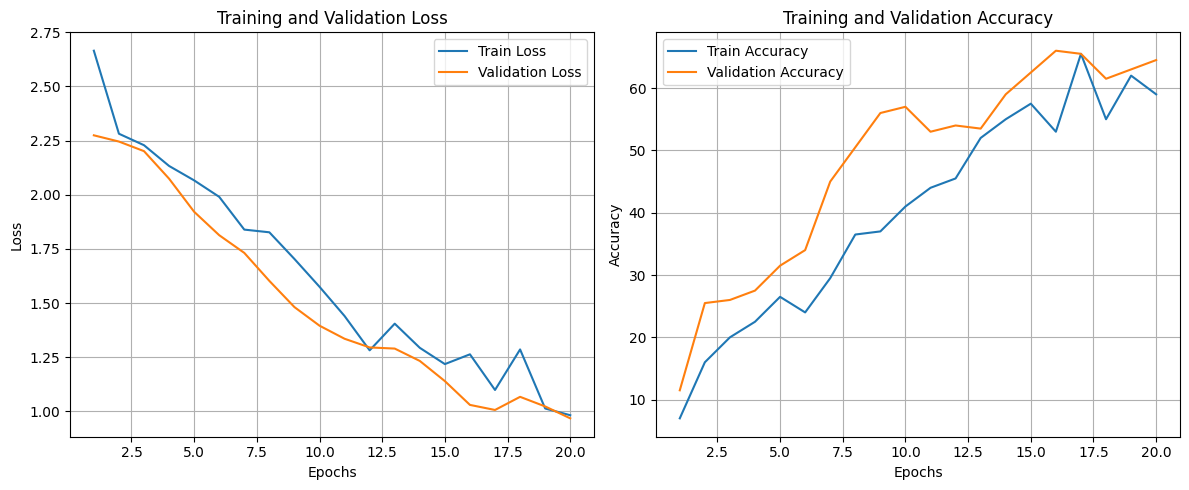

Acurácia da rede na base de teste: 64.50%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 42.02it/s]


Epoch 1, Train Loss: 2.372, Train Accuracy: 14.50%
Epoch 1, Val Loss: 2.214, Val Accuracy: 19.00%


100%|██████████| 4/4 [00:00<00:00, 43.92it/s]


Epoch 2, Train Loss: 2.169, Train Accuracy: 19.50%
Epoch 2, Val Loss: 2.118, Val Accuracy: 28.00%


...

Epoch 18, Train Loss: 1.087, Train Accuracy: 60.50%
Epoch 18, Val Loss: 0.944, Val Accuracy: 69.00%


100%|██████████| 4/4 [00:00<00:00, 41.50it/s]


Epoch 19, Train Loss: 0.881, Train Accuracy: 64.50%
Epoch 19, Val Loss: 0.992, Val Accuracy: 68.50%


100%|██████████| 4/4 [00:00<00:00, 42.87it/s]


Epoch 20, Train Loss: 0.960, Train Accuracy: 59.50%
Epoch 20, Val Loss: 0.888, Val Accuracy: 71.00%
Treinamento concluído
Número de neurônios na camada fully connected: 30


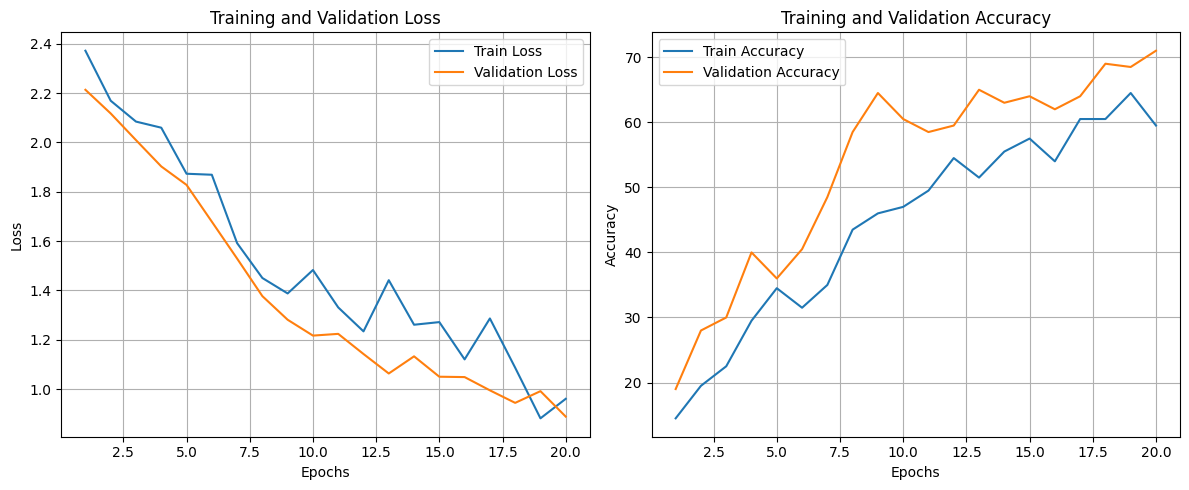

Acurácia da rede na base de teste: 71.00%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 41.74it/s]


Epoch 1, Train Loss: 2.485, Train Accuracy: 9.50%
Epoch 1, Val Loss: 2.175, Val Accuracy: 26.50%


100%|██████████| 4/4 [00:00<00:00, 40.92it/s]


Epoch 2, Train Loss: 2.259, Train Accuracy: 18.50%
Epoch 2, Val Loss: 2.151, Val Accuracy: 36.00%


...

Epoch 18, Train Loss: 1.121, Train Accuracy: 58.50%
Epoch 18, Val Loss: 0.952, Val Accuracy: 66.50%


100%|██████████| 4/4 [00:00<00:00, 41.75it/s]


Epoch 19, Train Loss: 0.992, Train Accuracy: 64.50%
Epoch 19, Val Loss: 0.980, Val Accuracy: 69.50%


100%|██████████| 4/4 [00:00<00:00, 43.85it/s]


Epoch 20, Train Loss: 0.945, Train Accuracy: 64.00%
Epoch 20, Val Loss: 0.973, Val Accuracy: 68.50%
Treinamento concluído
Número de neurônios na camada fully connected: 38


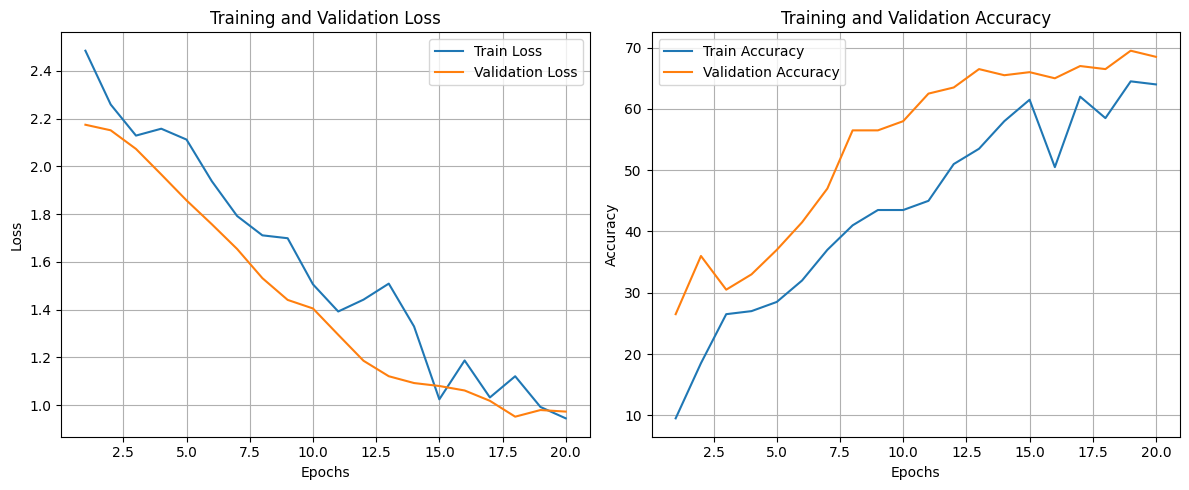

Acurácia da rede na base de teste: 68.50%
----------------------------------------------------------------------------------------------------
Iniciando o treinamento para a combinação (6, 16)


100%|██████████| 4/4 [00:00<00:00, 38.64it/s]


Epoch 1, Train Loss: 2.344, Train Accuracy: 11.00%
Epoch 1, Val Loss: 2.225, Val Accuracy: 11.50%


100%|██████████| 4/4 [00:00<00:00, 35.88it/s]


Epoch 2, Train Loss: 2.291, Train Accuracy: 11.50%
Epoch 2, Val Loss: 2.229, Val Accuracy: 26.50%


...

Epoch 19, Train Loss: 0.802, Train Accuracy: 66.00%


Epoch 19, Val Loss: 0.927, Val Accuracy: 66.50%


100%|██████████| 4/4 [00:00<00:00, 24.67it/s]

Epoch 20, Train Loss: 0.893, Train Accuracy: 67.50%


Epoch 20, Val Loss: 0.893, Val Accuracy: 69.00%
Treinamento concluído
Número de neurônios na camada fully connected: 48


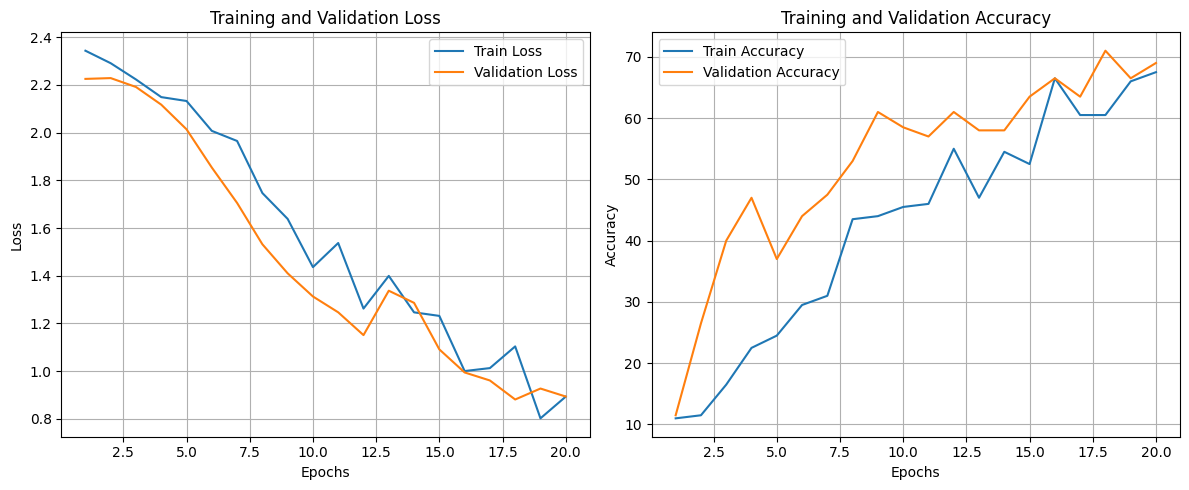

Acurácia da rede na base de teste: 69.00%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 38.00it/s]

Epoch 1, Train Loss: 2.263, Train Accuracy: 12.50%


Epoch 1, Val Loss: 2.201, Val Accuracy: 19.50%


100%|██████████| 4/4 [00:00<00:00, 34.64it/s]


...

Epoch 18, Train Loss: 0.962, Train Accuracy: 67.50%
Epoch 18, Val Loss: 0.901, Val Accuracy: 68.50%


100%|██████████| 4/4 [00:00<00:00, 38.51it/s]


Epoch 19, Train Loss: 0.776, Train Accuracy: 69.00%
Epoch 19, Val Loss: 1.038, Val Accuracy: 64.50%


100%|██████████| 4/4 [00:00<00:00, 39.23it/s]


Epoch 20, Train Loss: 0.995, Train Accuracy: 68.50%
Epoch 20, Val Loss: 0.914, Val Accuracy: 71.00%
Treinamento concluído
Número de neurônios na camada fully connected: 74


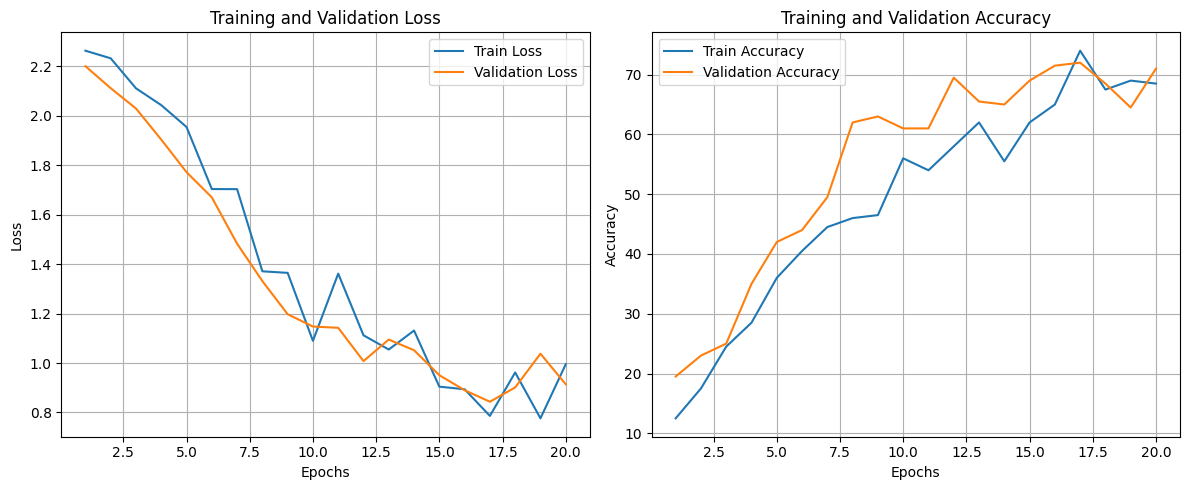

Acurácia da rede na base de teste: 71.00%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 39.23it/s]


Epoch 1, Train Loss: 2.314, Train Accuracy: 12.50%
Epoch 1, Val Loss: 2.218, Val Accuracy: 23.50%


100%|██████████| 4/4 [00:00<00:00, 35.54it/s]


Epoch 2, Train Loss: 2.217, Train Accuracy: 20.50%
Epoch 2, Val Loss: 2.143, Val Accuracy: 23.00%


...

Epoch 18, Train Loss: 0.791, Train Accuracy: 72.00%
Epoch 18, Val Loss: 0.881, Val Accuracy: 70.50%


100%|██████████| 4/4 [00:00<00:00, 33.83it/s]


Epoch 19, Train Loss: 0.756, Train Accuracy: 73.00%
Epoch 19, Val Loss: 0.843, Val Accuracy: 67.50%


100%|██████████| 4/4 [00:00<00:00, 37.95it/s]


Epoch 20, Train Loss: 0.868, Train Accuracy: 69.50%
Epoch 20, Val Loss: 0.880, Val Accuracy: 66.00%
Treinamento concluído
Número de neurônios na camada fully connected: 72


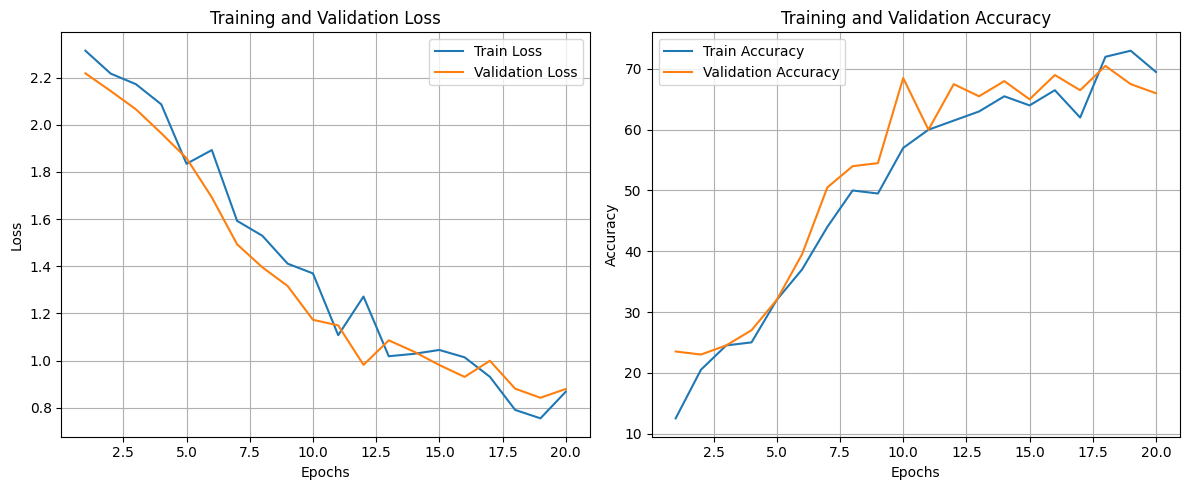

Acurácia da rede na base de teste: 66.00%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 37.20it/s]


Epoch 1, Train Loss: 2.396, Train Accuracy: 8.50%
Epoch 1, Val Loss: 2.294, Val Accuracy: 15.00%


100%|██████████| 4/4 [00:00<00:00, 33.59it/s]


Epoch 2, Train Loss: 2.248, Train Accuracy: 9.50%
Epoch 2, Val Loss: 2.221, Val Accuracy: 23.00%


...

Epoch 18, Train Loss: 0.890, Train Accuracy: 66.50%
Epoch 18, Val Loss: 0.861, Val Accuracy: 72.00%


100%|██████████| 4/4 [00:00<00:00, 41.27it/s]


Epoch 19, Train Loss: 0.877, Train Accuracy: 68.00%
Epoch 19, Val Loss: 0.865, Val Accuracy: 70.00%


100%|██████████| 4/4 [00:00<00:00, 36.00it/s]


Epoch 20, Train Loss: 0.677, Train Accuracy: 75.00%
Epoch 20, Val Loss: 0.893, Val Accuracy: 68.00%
Treinamento concluído
Número de neurônios na camada fully connected: 87


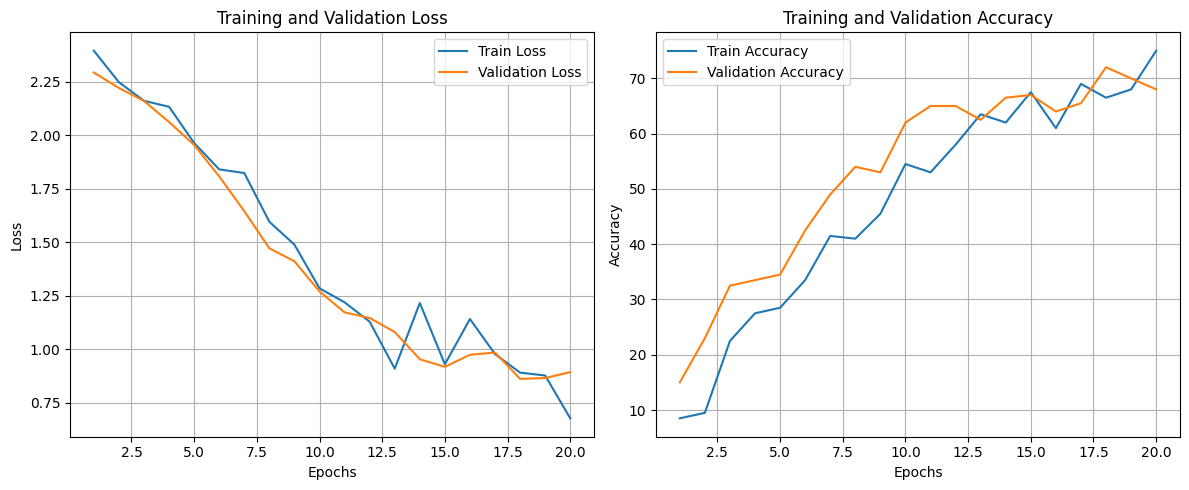

Acurácia da rede na base de teste: 68.00%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 40.13it/s]


Epoch 1, Train Loss: 2.384, Train Accuracy: 10.50%
Epoch 1, Val Loss: 2.271, Val Accuracy: 14.00%


100%|██████████| 4/4 [00:00<00:00, 38.33it/s]


Epoch 2, Train Loss: 2.269, Train Accuracy: 9.50%
Epoch 2, Val Loss: 2.249, Val Accuracy: 14.50%


...

Epoch 18, Val Loss: 1.087, Val Accuracy: 67.50%


100%|██████████| 4/4 [00:00<00:00, 34.73it/s]


Epoch 19, Train Loss: 1.139, Train Accuracy: 60.50%
Epoch 19, Val Loss: 1.075, Val Accuracy: 69.00%


100%|██████████| 4/4 [00:00<00:00, 34.41it/s]


Epoch 20, Train Loss: 0.989, Train Accuracy: 66.50%
Epoch 20, Val Loss: 1.073, Val Accuracy: 65.50%
Treinamento concluído
Número de neurônios na camada fully connected: 34


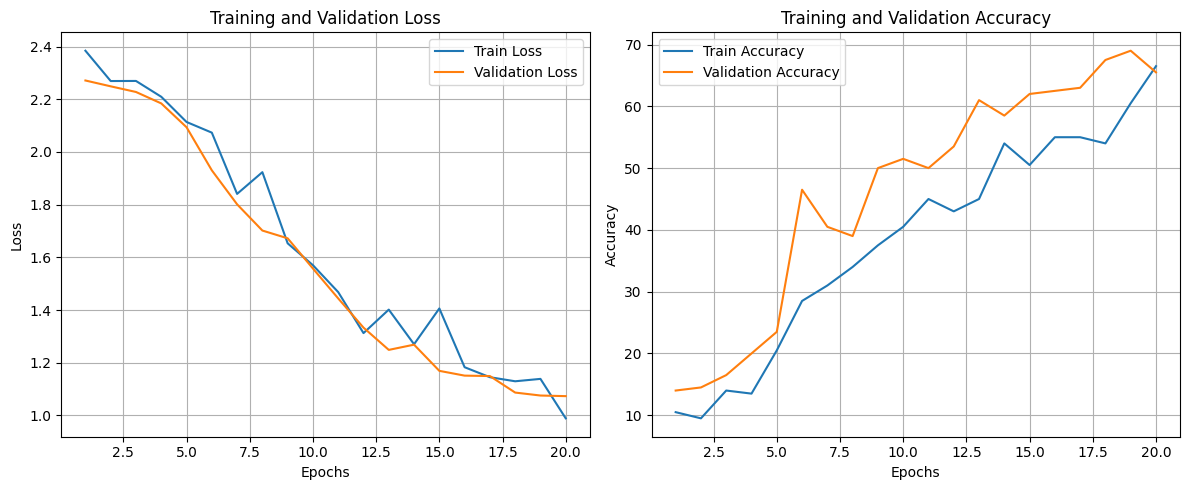

Acurácia da rede na base de teste: 65.50%
----------------------------------------------------------------------------------------------------
Iniciando o treinamento para a combinação (12, 8)


100%|██████████| 4/4 [00:00<00:00, 31.03it/s]

Epoch 1, Train Loss: 2.438, Train Accuracy: 11.00%


Epoch 1, Val Loss: 2.308, Val Accuracy: 9.50%


100%|██████████| 4/4 [00:00<00:00, 30.19it/s]

...

Epoch 19, Train Loss: 0.955, Train Accuracy: 60.50%


Epoch 19, Val Loss: 0.987, Val Accuracy: 62.50%


100%|██████████| 4/4 [00:00<00:00, 32.94it/s]

Epoch 20, Train Loss: 0.850, Train Accuracy: 68.00%


Epoch 20, Val Loss: 0.937, Val Accuracy: 65.50%
Treinamento concluído
Número de neurônios na camada fully connected: 52


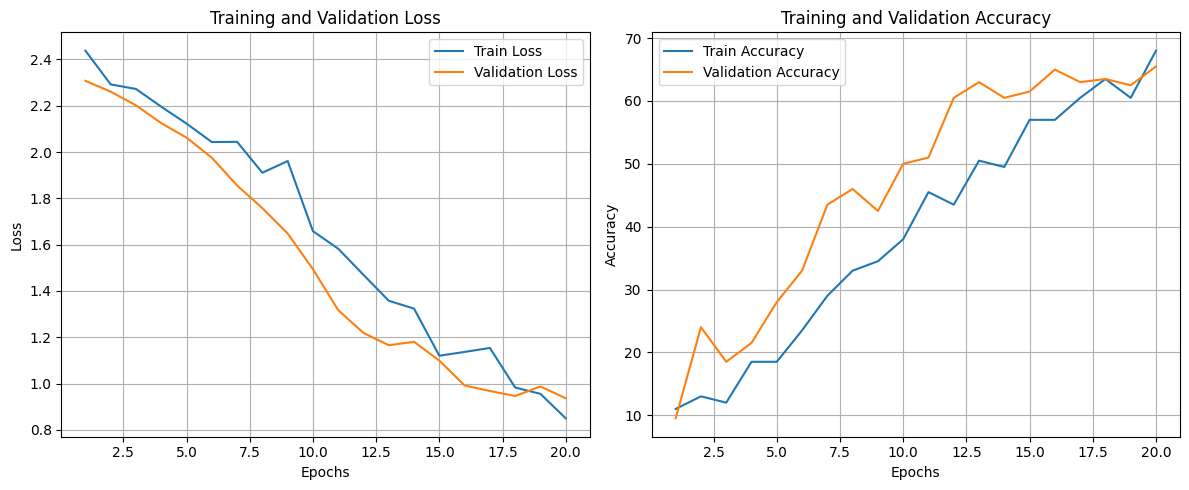

Acurácia da rede na base de teste: 65.50%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 26.15it/s]

Epoch 1, Train Loss: 2.416, Train Accuracy: 5.00%


Epoch 1, Val Loss: 2.294, Val Accuracy: 8.50%


100%|██████████| 4/4 [00:00<00:00, 22.90it/s]

...

Epoch 18, Train Loss: 1.536, Train Accuracy: 45.00%
Epoch 18, Val Loss: 1.359, Val Accuracy: 65.00%


100%|██████████| 4/4 [00:00<00:00, 23.97it/s]


Epoch 19, Train Loss: 1.419, Train Accuracy: 45.00%
Epoch 19, Val Loss: 1.328, Val Accuracy: 64.00%


100%|██████████| 4/4 [00:00<00:00, 22.02it/s]


Epoch 20, Train Loss: 1.448, Train Accuracy: 44.50%
Epoch 20, Val Loss: 1.297, Val Accuracy: 64.00%
Treinamento concluído
Número de neurônios na camada fully connected: 20


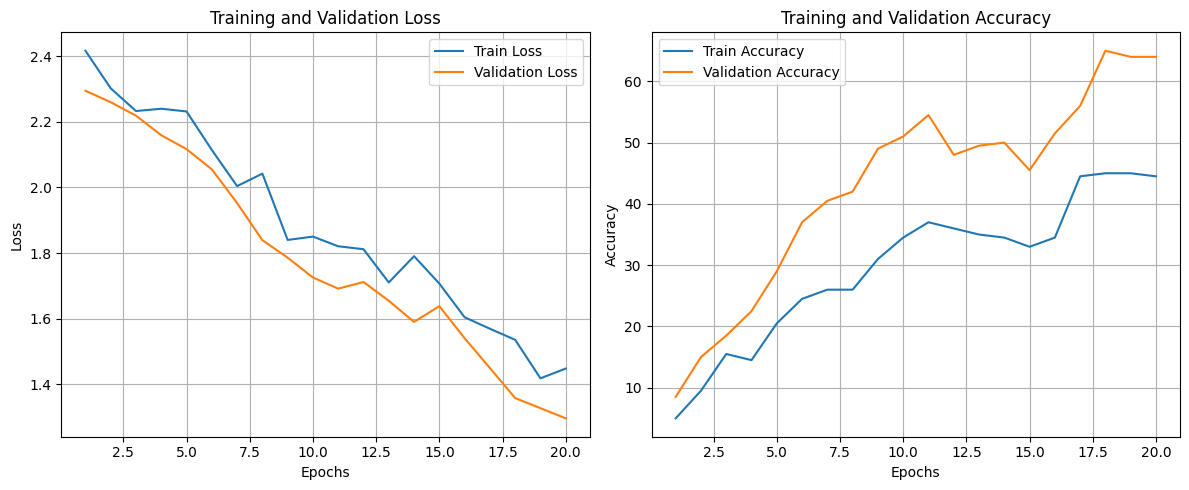

Acurácia da rede na base de teste: 64.00%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 26.59it/s]

Epoch 1, Train Loss: 2.301, Train Accuracy: 9.50%


Epoch 1, Val Loss: 2.299, Val Accuracy: 13.00%


100%|██████████| 4/4 [00:00<00:00, 24.66it/s]

...

Epoch 18, Train Loss: 1.550, Train Accuracy: 41.00%
Epoch 18, Val Loss: 1.431, Val Accuracy: 51.50%


100%|██████████| 4/4 [00:00<00:00, 31.93it/s]


Epoch 19, Train Loss: 1.304, Train Accuracy: 46.00%
Epoch 19, Val Loss: 1.387, Val Accuracy: 50.50%


100%|██████████| 4/4 [00:00<00:00, 32.99it/s]


Epoch 20, Train Loss: 1.448, Train Accuracy: 46.50%
Epoch 20, Val Loss: 1.419, Val Accuracy: 52.00%
Treinamento concluído
Número de neurônios na camada fully connected: 19


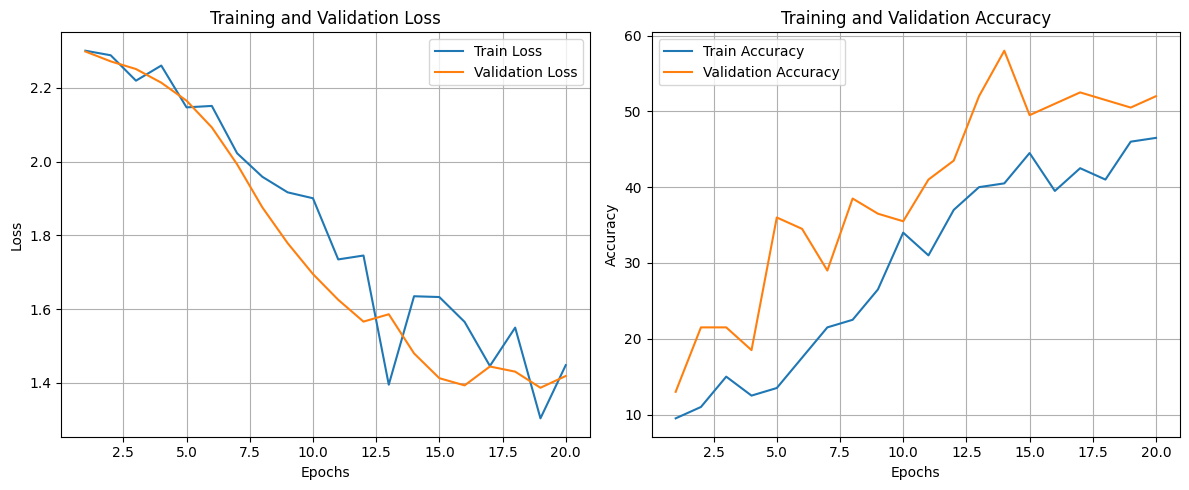

Acurácia da rede na base de teste: 52.00%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 31.74it/s]

Epoch 1, Train Loss: 2.415, Train Accuracy: 7.00%


Epoch 1, Val Loss: 2.315, Val Accuracy: 10.50%


100%|██████████| 4/4 [00:00<00:00, 26.57it/s]

...

Epoch 18, Train Loss: 1.057, Train Accuracy: 63.00%
Epoch 18, Val Loss: 1.056, Val Accuracy: 66.00%


100%|██████████| 4/4 [00:00<00:00, 17.45it/s]


Epoch 19, Train Loss: 1.036, Train Accuracy: 58.00%
Epoch 19, Val Loss: 0.961, Val Accuracy: 66.50%


100%|██████████| 4/4 [00:00<00:00, 28.79it/s]


Epoch 20, Train Loss: 0.943, Train Accuracy: 64.50%
Epoch 20, Val Loss: 0.867, Val Accuracy: 71.00%
Treinamento concluído
Número de neurônios na camada fully connected: 58


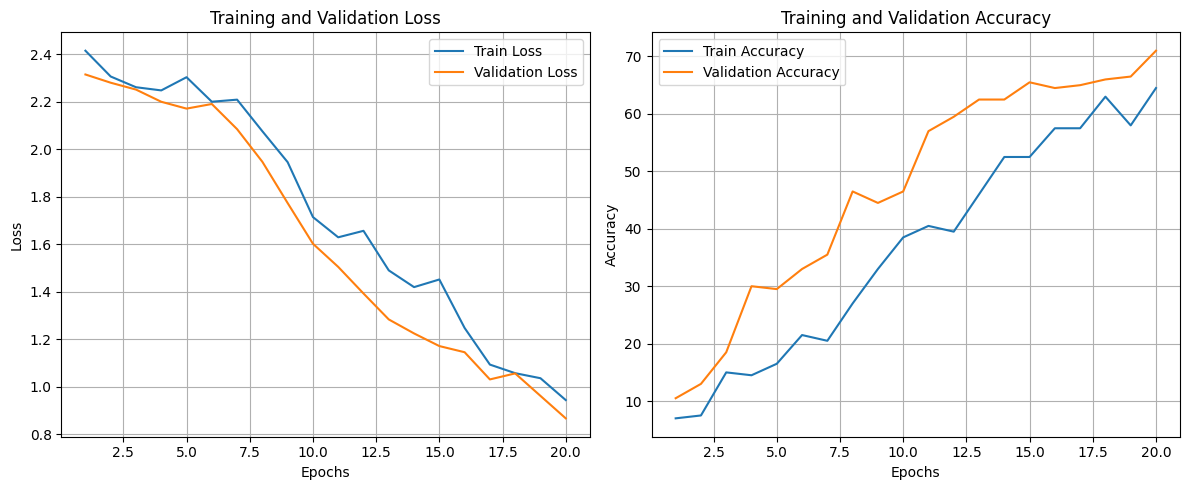

Acurácia da rede na base de teste: 71.00%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 31.67it/s]

Epoch 1, Train Loss: 2.380, Train Accuracy: 8.00%


Epoch 1, Val Loss: 2.276, Val Accuracy: 21.00%


100%|██████████| 4/4 [00:00<00:00, 24.25it/s]

...

Epoch 19, Train Loss: 1.399, Train Accuracy: 38.00%


Epoch 19, Val Loss: 1.292, Val Accuracy: 53.00%


100%|██████████| 4/4 [00:00<00:00, 30.30it/s]

Epoch 20, Train Loss: 1.306, Train Accuracy: 50.50%


Epoch 20, Val Loss: 1.256, Val Accuracy: 52.50%
Treinamento concluído
Número de neurônios na camada fully connected: 24


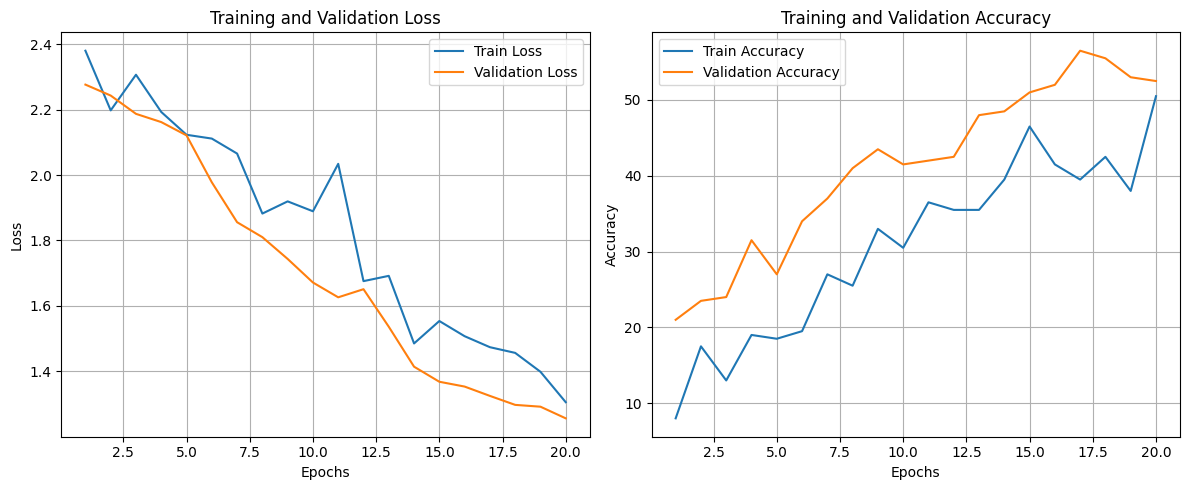

Acurácia da rede na base de teste: 52.50%
----------------------------------------------------------------------------------------------------
Iniciando o treinamento para a combinação (12, 16)


100%|██████████| 4/4 [00:00<00:00, 29.81it/s]

Epoch 1, Train Loss: 2.385, Train Accuracy: 9.00%


Epoch 1, Val Loss: 2.275, Val Accuracy: 9.50%


100%|██████████| 4/4 [00:00<00:00, 23.36it/s]

...

Epoch 18, Train Loss: 1.177, Train Accuracy: 50.00%
Epoch 18, Val Loss: 1.004, Val Accuracy: 66.00%


100%|██████████| 4/4 [00:00<00:00, 21.54it/s]


Epoch 19, Train Loss: 1.096, Train Accuracy: 56.00%
Epoch 19, Val Loss: 0.934, Val Accuracy: 64.50%


100%|██████████| 4/4 [00:00<00:00, 25.55it/s]


Epoch 20, Train Loss: 1.122, Train Accuracy: 55.00%
Epoch 20, Val Loss: 0.959, Val Accuracy: 66.00%
Treinamento concluído
Número de neurônios na camada fully connected: 25


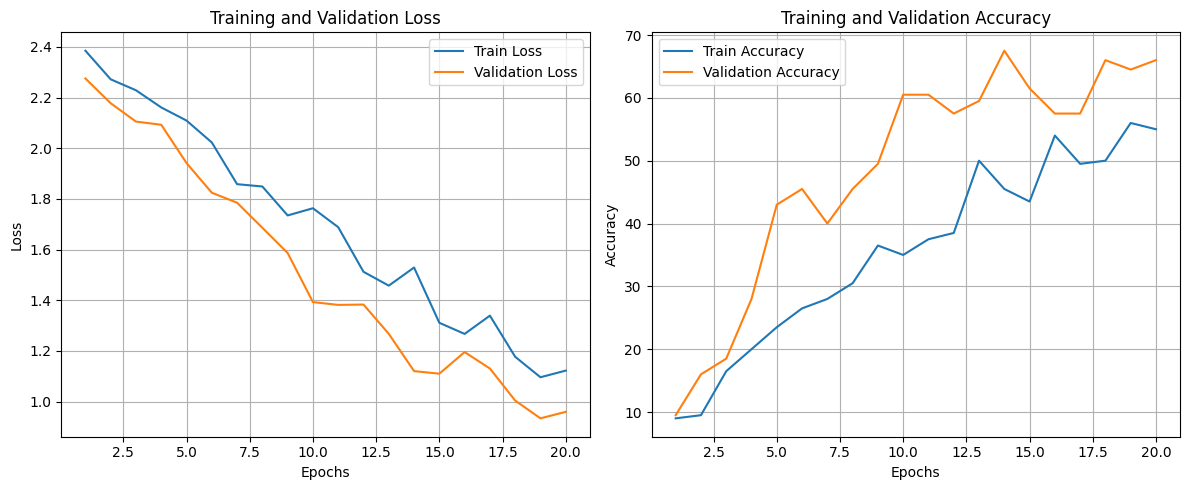

Acurácia da rede na base de teste: 66.00%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 18.34it/s]


Epoch 1, Train Loss: 2.326, Train Accuracy: 13.50%
Epoch 1, Val Loss: 2.249, Val Accuracy: 19.50%


100%|██████████| 4/4 [00:00<00:00, 18.59it/s]


Epoch 2, Train Loss: 2.195, Train Accuracy: 20.50%
Epoch 2, Val Loss: 2.182, Val Accuracy: 28.00%


...

Epoch 18, Train Loss: 1.466, Train Accuracy: 43.00%
Epoch 18, Val Loss: 1.390, Val Accuracy: 57.50%


100%|██████████| 4/4 [00:00<00:00, 29.27it/s]


Epoch 19, Train Loss: 1.402, Train Accuracy: 41.50%
Epoch 19, Val Loss: 1.235, Val Accuracy: 56.50%


100%|██████████| 4/4 [00:00<00:00, 29.55it/s]


Epoch 20, Train Loss: 1.412, Train Accuracy: 44.50%
Epoch 20, Val Loss: 1.206, Val Accuracy: 54.50%
Treinamento concluído
Número de neurônios na camada fully connected: 19


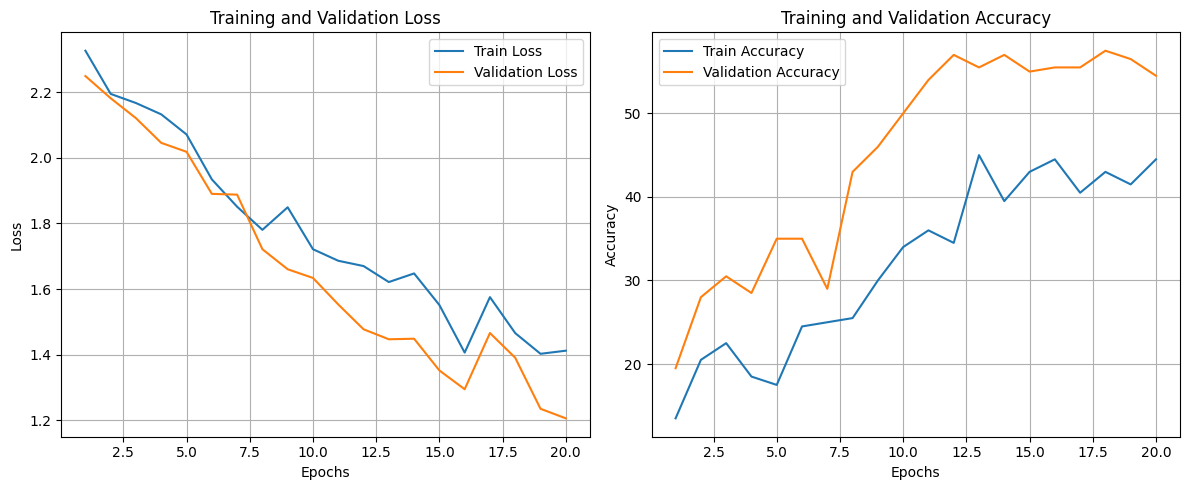

Acurácia da rede na base de teste: 54.50%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 28.25it/s]

Epoch 1, Train Loss: 2.314, Train Accuracy: 13.50%


Epoch 1, Val Loss: 2.221, Val Accuracy: 18.00%


100%|██████████| 4/4 [00:00<00:00, 26.16it/s]

...

Epoch 19, Train Loss: 0.765, Train Accuracy: 74.50%


Epoch 19, Val Loss: 0.904, Val Accuracy: 71.00%


100%|██████████| 4/4 [00:00<00:00, 27.95it/s]

Epoch 20, Train Loss: 0.790, Train Accuracy: 71.00%


Epoch 20, Val Loss: 0.917, Val Accuracy: 70.00%
Treinamento concluído
Número de neurônios na camada fully connected: 94


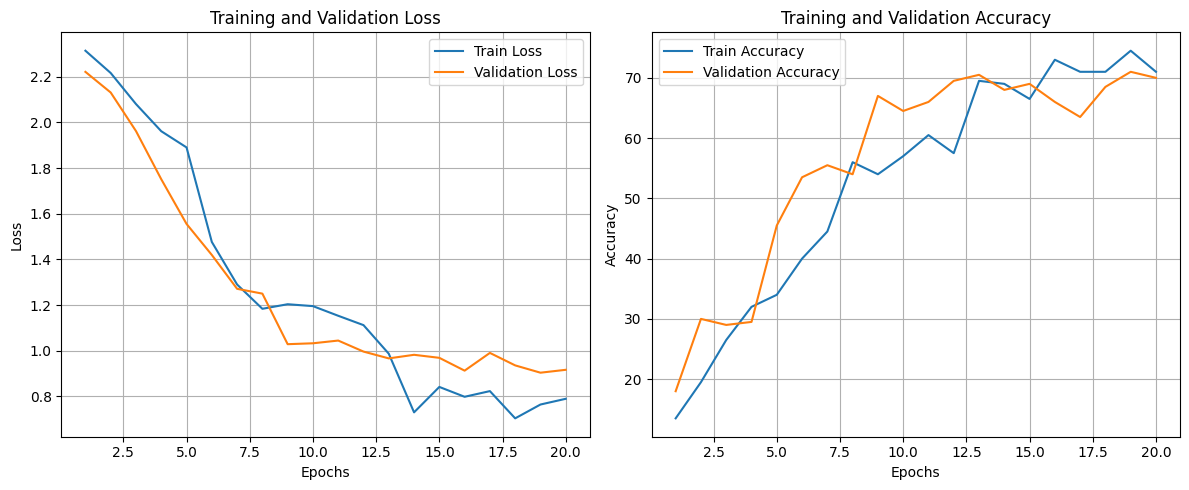

Acurácia da rede na base de teste: 70.00%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 20.11it/s]


Epoch 1, Train Loss: 2.435, Train Accuracy: 13.50%
Epoch 1, Val Loss: 2.251, Val Accuracy: 25.00%


100%|██████████| 4/4 [00:00<00:00, 19.04it/s]


Epoch 2, Train Loss: 2.255, Train Accuracy: 23.00%
Epoch 2, Val Loss: 2.195, Val Accuracy: 32.50%


...

Epoch 18, Train Loss: 0.765, Train Accuracy: 69.00%
Epoch 18, Val Loss: 0.876, Val Accuracy: 68.00%


100%|██████████| 4/4 [00:00<00:00, 28.68it/s]


Epoch 19, Train Loss: 0.832, Train Accuracy: 75.50%
Epoch 19, Val Loss: 0.895, Val Accuracy: 69.50%


100%|██████████| 4/4 [00:00<00:00, 23.89it/s]


Epoch 20, Train Loss: 0.613, Train Accuracy: 72.50%
Epoch 20, Val Loss: 0.965, Val Accuracy: 68.50%
Treinamento concluído
Número de neurônios na camada fully connected: 73


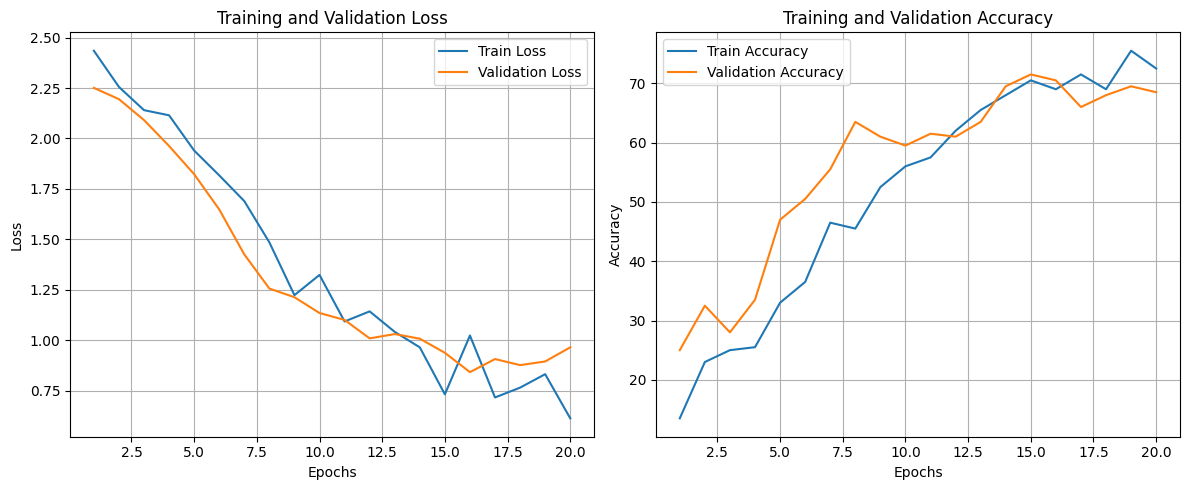

Acurácia da rede na base de teste: 68.50%
----------------------------------------------------------------------------------------------------


100%|██████████| 4/4 [00:00<00:00, 28.29it/s]

Epoch 1, Train Loss: 2.305, Train Accuracy: 15.50%


Epoch 1, Val Loss: 2.274, Val Accuracy: 14.50%


100%|██████████| 4/4 [00:00<00:00, 24.97it/s]

...

Epoch 19, Train Loss: 1.523, Train Accuracy: 47.50%


Epoch 19, Val Loss: 1.330, Val Accuracy: 58.00%


100%|██████████| 4/4 [00:00<00:00, 24.32it/s]

Epoch 20, Train Loss: 1.514, Train Accuracy: 40.50%


Epoch 20, Val Loss: 1.285, Val Accuracy: 61.50%
Treinamento concluído
Número de neurônios na camada fully connected: 12


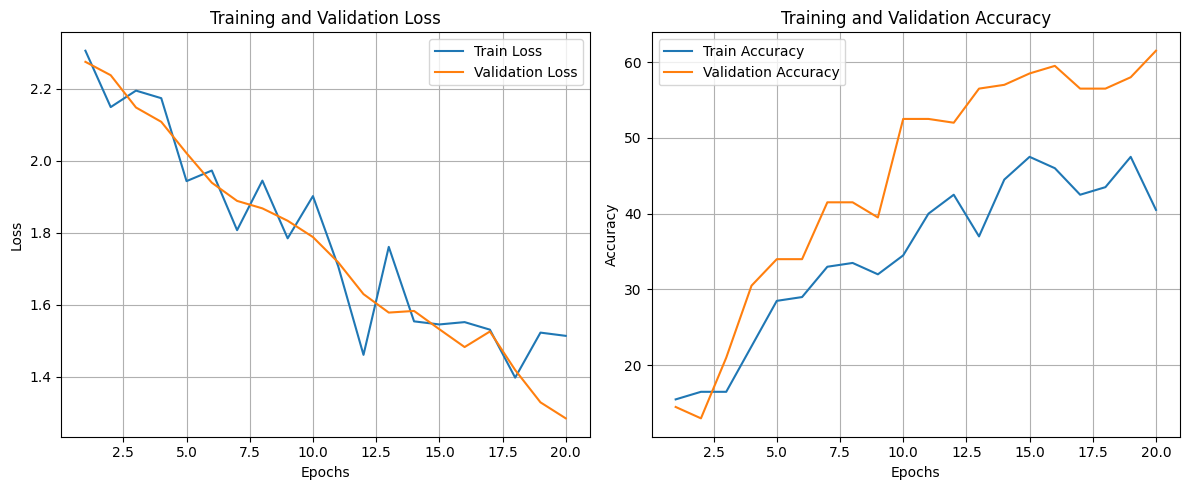

Acurácia da rede na base de teste: 61.50%
----------------------------------------------------------------------------------------------------


In [ ]:
filtro_1 = [6,12]
filtro_2 = [8,16]

for num_1 in filtro_1:
  for num_2 in filtro_2:
    print(f"Iniciando o treinamento para a combinação {num_1,num_2}")
    for i in range(5):
      num_neurons= np.random.randint(10,100)
      model = CNN_Alt(
          initialize_weights=True,
          dropout=0.5,
          out_c1=num_1,
          out_c2=num_2,
          out_fc1=num_neurons
      )

      criterion_1 = nn.CrossEntropyLoss()
      optimizer_1 = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

      # Treinando a CNN
      history_1 = train_model(
          model=model,
          trainloader=train_loader,
          valloader=val_loader,
          criterion=criterion_1,
          optimizer=optimizer_1,
          num_epochs=20
      )

      print(f'Número de neurônios na camada fully connected: {num_neurons}')

      plot_training_history(history_1)

      test_model(model, val_loader)
      print('-'*100)

Observações:
* O valor de 71% de acurácia foi o melhor resultado, sendo encontrado em três combinações distintas de filtros e número de neurônios.São eles:
6,8 (2 vezes) e 12,8